## 1. Preprocesamiento de Datos
### 1.1 Importar Librerias, carga e inspeccion inicial

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("data/dataset_generacion_anual_de_residuos_solidos_domiciliarios_y_municipales.csv", encoding="latin-1", sep=";")
df = df.rename(columns={"GENERACION_DOM URBANA_TANIO": "GENERACION_DOM_URBANA_TANIO"})
df.head()

,FECHA_CORTE,UBIGEO,ANIO,DEPARTAMENTO,PROVINCIA,DISTRITO,REGION_NATURAL,TIPO_MUNICIPALIDAD,POB_TOTAL_INEI,POB_URBANA_INEI,POB_RURAL_INEI,CLASIFICACION_MUNICIPAL_MEF,GENERACION_PER_CAPITA_DOM,GENERACION_DOM_URBANA_TDIA,GENERACION_DOM_URBANA_TANIO,GENERACION_MUN_TANIO,GENERACION_MUN_TDIA,GENERACION_PER_CAPITA_MUNICIPAL
0,18122025,10101,2024,AMAZONAS,CHACHAPOYAS,CHACHAPOYAS,SELVA,PROVINCIAL,41335,40358,977,A,0.50,20.18,7365.34,10521.91,28.83,0.71
1,18122025,10102,2024,AMAZONAS,CHACHAPOYAS,ASUNCION,SELVA,DISTRITAL,271,130,141,F,0.53,0.07,25.15,35.93,0.10,0.76
2,18122025,10103,2024,AMAZONAS,CHACHAPOYAS,BALSAS,SIERRA,DISTRITAL,1137,276,861,G,0.45,0.12,45.33,64.76,0.18,0.64
3,18122025,10104,2024,AMAZONAS,CHACHAPOYAS,CHETO,SIERRA,DISTRITAL,713,448,265,F,0.45,0.20,73.58,105.12,0.29,0.64
4,18122025,10105,2024,AMAZONAS,CHACHAPOYAS,CHILIQUIN,SIERRA,DISTRITAL,561,144,417,G,0.45,0.06,23.65,33.79,0.09,0.64


In [4]:
print("Dimensiones del dataset:", df.shape)

print("\nColumnas disponibles:")
print(df.columns.tolist())
print("\n")

df.info()

# Limpieza de texto en columnas categóricas (espacios y mayúsculas inconsistentes)
for col in ["DEPARTAMENTO", "PROVINCIA", "DISTRITO", "REGION_NATURAL", "TIPO_MUNICIPALIDAD"]:
    df[col] = df[col].str.strip().str.upper()

print("Departamentos únicos:", df["DEPARTAMENTO"].nunique())
print(sorted(df["DEPARTAMENTO"].unique()))

Dimensiones del dataset: (11310, 18)

Columnas disponibles:
['FECHA_CORTE', 'UBIGEO', 'ANIO', 'DEPARTAMENTO', 'PROVINCIA', 'DISTRITO', 'REGION_NATURAL', 'TIPO_MUNICIPALIDAD', 'POB_TOTAL_INEI', 'POB_URBANA_INEI', 'POB_RURAL_INEI', 'CLASIFICACION_MUNICIPAL_MEF', 'GENERACION_PER_CAPITA_DOM', 'GENERACION_DOM_URBANA_TDIA', 'GENERACION_DOM_URBANA_TANIO', 'GENERACION_MUN_TANIO', 'GENERACION_MUN_TDIA', 'GENERACION_PER_CAPITA_MUNICIPAL']


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11310 entries, 0 to 11309
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   FECHA_CORTE                      11310 non-null  int64  
 1   UBIGEO                           11310 non-null  int64  
 2   ANIO                             11310 non-null  int64  
 3   DEPARTAMENTO                     11310 non-null  object 
 4   PROVINCIA                        11310 non-null  object 
 5   DISTRITO         

### 1.2 Tratamiento de valores faltantes
Afortunadamente, este dataset no tiene valores nulos

### 1.3 Deteccion y tratamiento de Outliers (IQR)

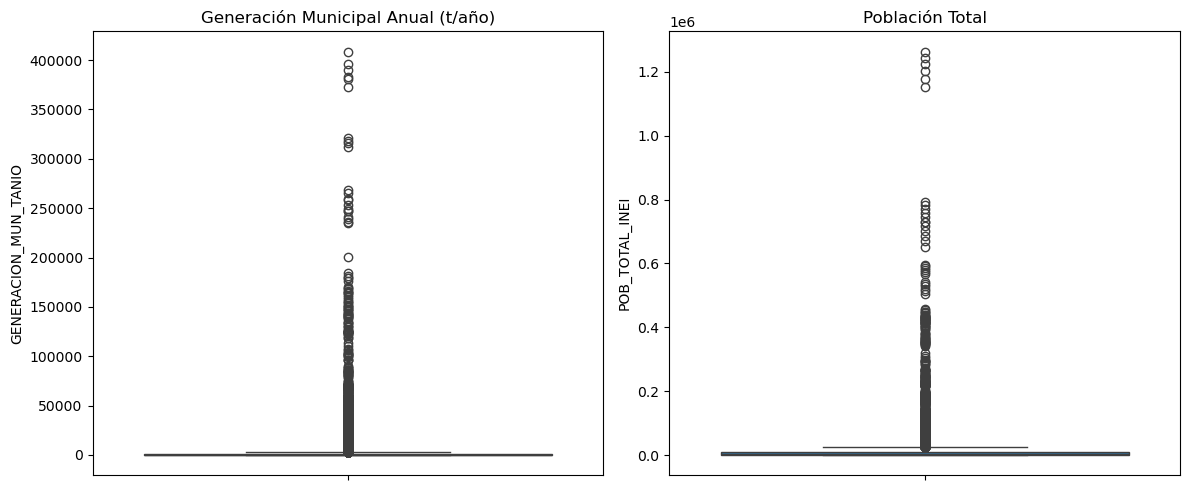

Límites IQR: [-1526.89, 2838.16] toneladas/año
Distritos identificados como outliers: 1880


,DISTRITO,DEPARTAMENTO,GENERACION_MUN_TANIO
1324,SAN JUAN DE LURIGANCHO,LIMA,408652.54
3215,SAN JUAN DE LURIGANCHO,LIMA,396045.05
5105,SAN JUAN DE LURIGANCHO,LIMA,389666.76
6995,SAN JUAN DE LURIGANCHO,LIMA,382679.69
8873,SAN JUAN DE LURIGANCHO,LIMA,380710.63
10747,SAN JUAN DE LURIGANCHO,LIMA,372508.55
5108,SAN MARTIN DE PORRES,LIMA,321502.43
8876,SAN MARTIN DE PORRES,LIMA,318134.52
6998,SAN MARTIN DE PORRES,LIMA,316284.39
10750,SAN MARTIN DE PORRES,LIMA,311814.16


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df["GENERACION_MUN_TANIO"], ax=axes[0])
axes[0].set_title("Generación Municipal Anual (t/año)")
sns.boxplot(y=df["POB_TOTAL_INEI"], ax=axes[1])
axes[1].set_title("Población Total")
plt.tight_layout()
plt.show()

def limites_iqr(serie):
    Q1, Q3 = serie.quantile(0.25), serie.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

lim_inf, lim_sup = limites_iqr(df["GENERACION_MUN_TANIO"])
outliers = df[(df["GENERACION_MUN_TANIO"] < lim_inf) | (df["GENERACION_MUN_TANIO"] > lim_sup)]

print(f"Límites IQR: [{lim_inf:.2f}, {lim_sup:.2f}] toneladas/año")
print(f"Distritos identificados como outliers: {len(outliers)}")
outliers[["DISTRITO", "DEPARTAMENTO", "GENERACION_MUN_TANIO"]].sort_values("GENERACION_MUN_TANIO", ascending=False).head(10)

In [6]:
df["ES_OUTLIER_GENERACION"] = (df["GENERACION_MUN_TANIO"] < lim_inf) | (df["GENERACION_MUN_TANIO"] > lim_sup)

# CONFIGURACIÓN DEL EXPERIMENTO
SEPARAR_OUTLIERS_KMEANS = True
# False para comparar que pasa al no separar los outliers del K-Means

if SEPARAR_OUTLIERS_KMEANS:
    df_normal = df[~df["ES_OUTLIER_GENERACION"]].copy()
    df_outliers = df[df["ES_OUTLIER_GENERACION"]].copy()
else:
    df_normal = df.copy()
    df_outliers = df.iloc[0:0].copy()  # vacío, mismas columnas, para que el resto del código no falle

print(f"Modo: {'CON separación' if SEPARAR_OUTLIERS_KMEANS else 'SIN separación'}")
print(f"Distritos para K-Means: {len(df_normal)}")
print(f"Distritos tratados aparte: {len(df_outliers)}")

Modo: CON separación
Distritos para K-Means: 9430
Distritos tratados aparte: 1880


### 1.4 Codificacion de variables categoricas

In [7]:
df_normal_encoded = df_normal.copy()

le_region = LabelEncoder()
df_normal_encoded["REGION_NATURAL_COD"] = le_region.fit_transform(df_normal_encoded["REGION_NATURAL"])

df_normal_encoded = pd.get_dummies(df_normal_encoded, columns=["TIPO_MUNICIPALIDAD", "CLASIFICACION_MUNICIPAL_MEF"], prefix=["TIPO", "MEF"])

df_normal_encoded.head()

,FECHA_CORTE,UBIGEO,ANIO,DEPARTAMENTO,PROVINCIA,DISTRITO,REGION_NATURAL,POB_TOTAL_INEI,POB_URBANA_INEI,POB_RURAL_INEI,...,REGION_NATURAL_COD,TIPO_DISTRITAL,TIPO_PROVINCIAL,MEF_B,MEF_C,MEF_D,MEF_E,MEF_F,MEF_G,MEF_No disponible
1,18122025,10102,2024,AMAZONAS,CHACHAPOYAS,ASUNCION,SELVA,271,130,141,...,2,True,False,False,False,False,False,True,False,False
2,18122025,10103,2024,AMAZONAS,CHACHAPOYAS,BALSAS,SIERRA,1137,276,861,...,3,True,False,False,False,False,False,False,True,False
3,18122025,10104,2024,AMAZONAS,CHACHAPOYAS,CHETO,SIERRA,713,448,265,...,3,True,False,False,False,False,False,True,False,False
4,18122025,10105,2024,AMAZONAS,CHACHAPOYAS,CHILIQUIN,SIERRA,561,144,417,...,3,True,False,False,False,False,False,False,True,False
5,18122025,10106,2024,AMAZONAS,CHACHAPOYAS,CHUQUIBAMBA,SIERRA,1884,437,1447,...,3,True,False,False,False,False,False,False,True,False


**Nota (Jhair)** La categoría MEF "A" no aparece en `df_normal` porque corresponde a las
municipalidades de mayor envergadura (Lima y otras ciudades principales), las cuales
ya fueron separadas como outliers en la etapa de detección de IQR. Esto confirma la
coherencia entre ambos criterios de clasificación.

In [8]:
print("Categorias MEF en df_normal:", sorted(df_normal["CLASIFICACION_MUNICIPAL_MEF"].unique()))
print("Categorias MEF en df_outliers:", sorted(df_outliers["CLASIFICACION_MUNICIPAL_MEF"].unique()))

Categorias MEF en df_normal: ['B', 'C', 'D', 'E', 'F', 'G', 'No disponible']
Categorias MEF en df_outliers: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'No disponible']


### 1.5 Normalizacion

In [9]:
variables_numericas = ["GENERACION_MUN_TANIO", "GENERACION_PER_CAPITA_MUNICIPAL", "POB_TOTAL_INEI"]

scaler = StandardScaler()
df_normal_scaled = df_normal_encoded.copy()
df_normal_scaled[variables_numericas] = scaler.fit_transform(df_normal_encoded[variables_numericas])

df_normal_scaled[variables_numericas].describe()

,GENERACION_MUN_TANIO,GENERACION_PER_CAPITA_MUNICIPAL,POB_TOTAL_INEI
count,9.430000e+03,9.430000e+03,9.430000e+03
mean,-6.027934e-18,1.092563e-16,8.439108e-17
std,1.000053e+00,1.000053e+00,1.000053e+00
min,-7.742959e-01,-3.122966e+00,-9.190228e-01
25%,-6.193133e-01,-1.684583e-01,-6.851849e-01
50%,-4.095958e-01,-1.042299e-01,-3.595678e-01
75%,1.577298e-01,4.095976e-01,3.563917e-01
max,4.249265e+00,1.421871e+01,6.740407e+00


**Nota (Jhair)** 
Esta de abajo es la tabla con valores normalizados redondeados

In [10]:
tabla_normalizacion = df_normal_scaled[variables_numericas].describe().round(2)
tabla_normalizacion

,GENERACION_MUN_TANIO,GENERACION_PER_CAPITA_MUNICIPAL,POB_TOTAL_INEI
count,9430.00,9430.00,9430.00
mean,-0.00,0.00,0.00
std,1.00,1.00,1.00
min,-0.77,-3.12,-0.92
25%,-0.62,-0.17,-0.69
50%,-0.41,-0.10,-0.36
75%,0.16,0.41,0.36
max,4.25,14.22,6.74


## 2. Analisis Exploratorio de Datos (EDA)
### 2.1 Evolucion anual de la generacion municipal por departamento

C:\Users\ANDRES\AppData\Local\Temp\ipykernel_67792\3371358986.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colores = cm.get_cmap("tab20", len(departamentos))


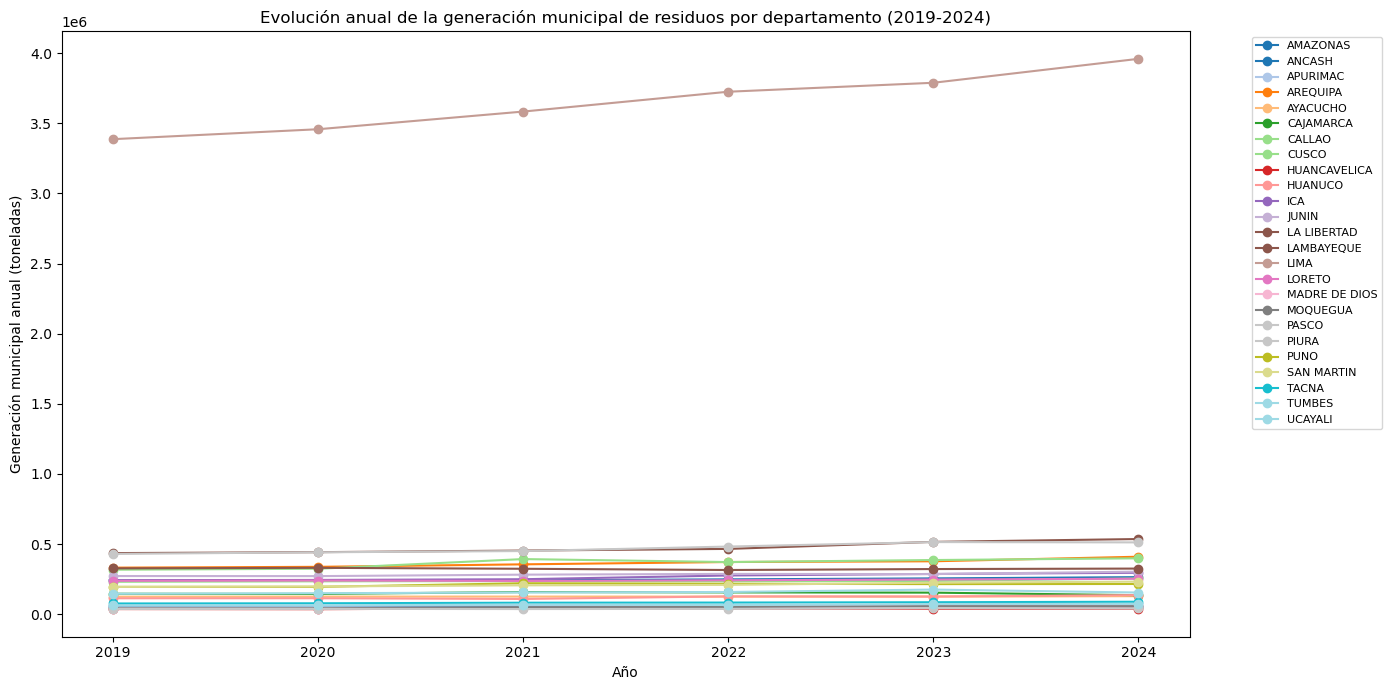

In [11]:
import matplotlib.cm as cm

generacion_anual_depto = df.groupby(["ANIO", "DEPARTAMENTO"])["GENERACION_MUN_TANIO"].sum().reset_index()
departamentos = generacion_anual_depto["DEPARTAMENTO"].unique()
colores = cm.get_cmap("tab20", len(departamentos))

plt.figure(figsize=(14, 7))
for i, depto in enumerate(departamentos):
    datos_depto = generacion_anual_depto[generacion_anual_depto["DEPARTAMENTO"] == depto]
    plt.plot(datos_depto["ANIO"], datos_depto["GENERACION_MUN_TANIO"], marker="o", label=depto, color=colores(i))

plt.title("Evolución anual de la generación municipal de residuos por departamento (2019-2024)")
plt.xlabel("Año")
plt.ylabel("Generación municipal anual (toneladas)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### 2.2 Distribución de la generacion per capita por region natural

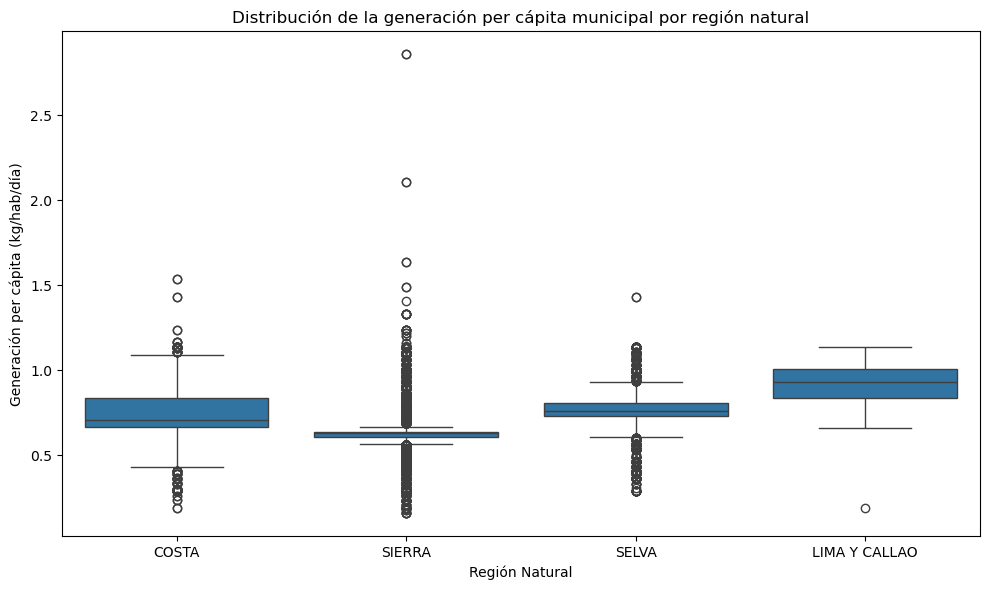

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="REGION_NATURAL", y="GENERACION_PER_CAPITA_MUNICIPAL", order=["COSTA", "SIERRA", "SELVA", "LIMA Y CALLAO"])
plt.title("Distribución de la generación per cápita municipal por región natural")
plt.xlabel("Región Natural")
plt.ylabel("Generación per cápita (kg/hab/día)")
plt.tight_layout()
plt.show()

### 2.3 Mapa de calor de correlaciones

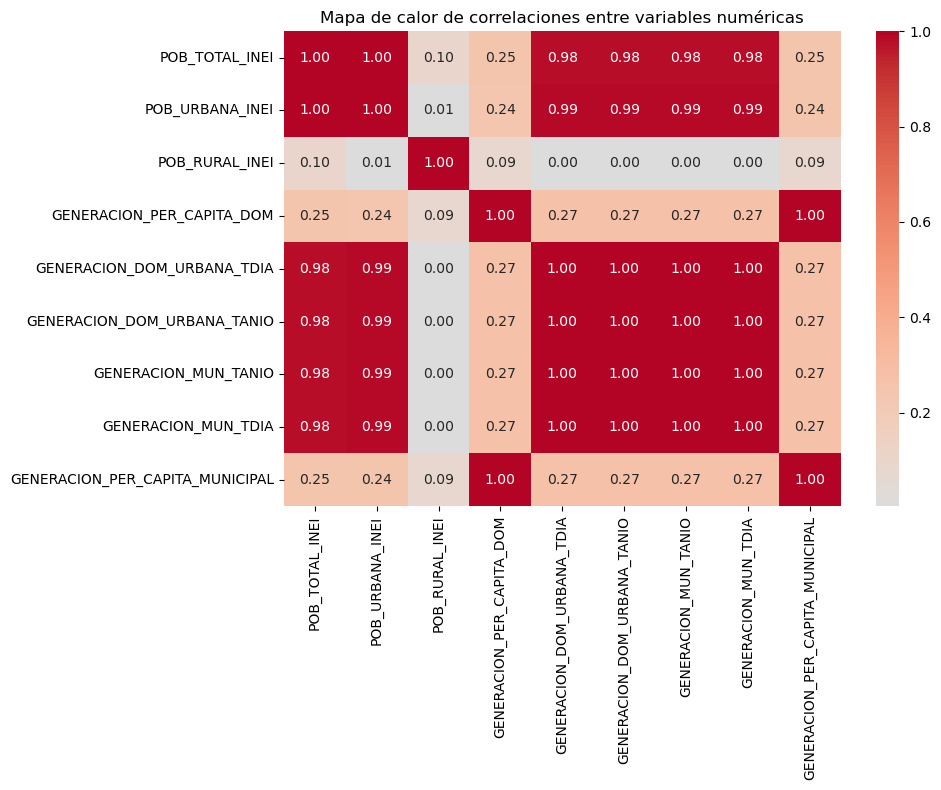

In [13]:
variables_correlacion = ["POB_TOTAL_INEI", "POB_URBANA_INEI", "POB_RURAL_INEI", 
                           "GENERACION_PER_CAPITA_DOM", "GENERACION_DOM_URBANA_TDIA",
                           "GENERACION_DOM_URBANA_TANIO", "GENERACION_MUN_TANIO", 
                           "GENERACION_MUN_TDIA", "GENERACION_PER_CAPITA_MUNICIPAL"]

matriz_corr = df[variables_correlacion].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Mapa de calor de correlaciones entre variables numéricas")
plt.tight_layout()
plt.show()

### 2.4 Histogramas de distribucion (asimetria y normalidad)

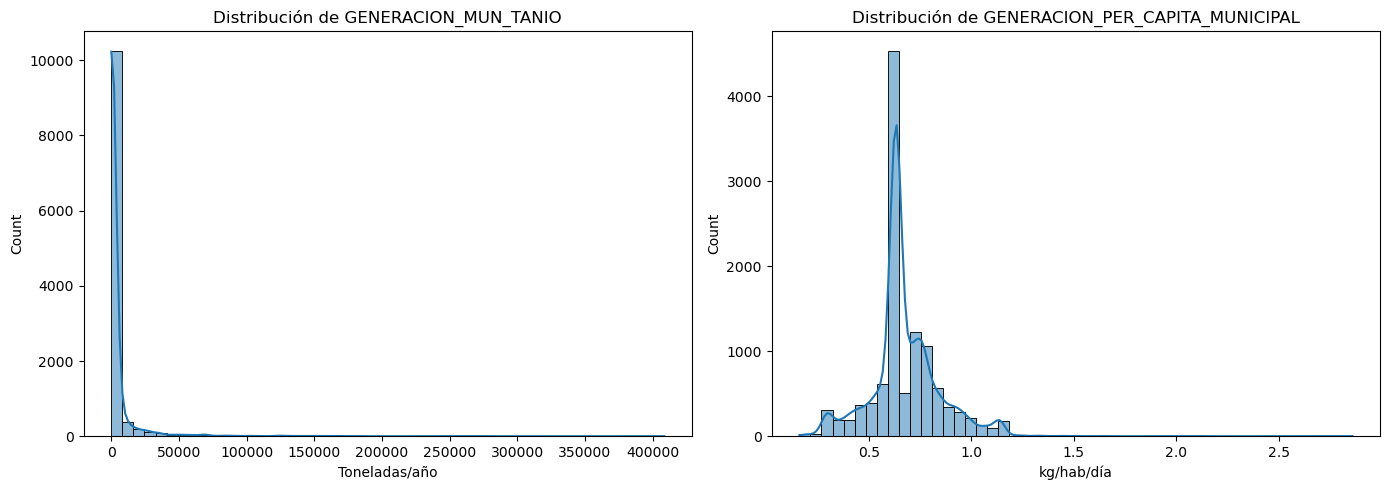

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["GENERACION_MUN_TANIO"], bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribución de GENERACION_MUN_TANIO")
axes[0].set_xlabel("Toneladas/año")

sns.histplot(df["GENERACION_PER_CAPITA_MUNICIPAL"], bins=50, kde=True, ax=axes[1])
axes[1].set_title("Distribución de GENERACION_PER_CAPITA_MUNICIPAL")
axes[1].set_xlabel("kg/hab/día")

plt.tight_layout()
plt.show()

### 2.5 Gráficos de barras: generación por tipo de municipalidad y clasificación MEF

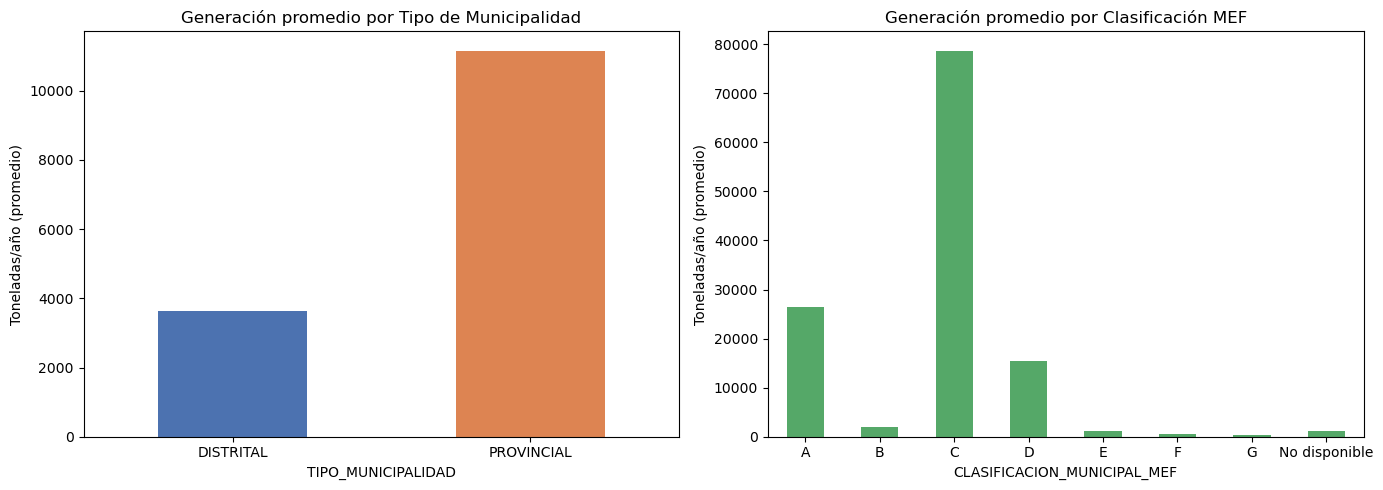

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby("TIPO_MUNICIPALIDAD")["GENERACION_MUN_TANIO"].mean().plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Generación promedio por Tipo de Municipalidad")
axes[0].set_ylabel("Toneladas/año (promedio)")
axes[0].tick_params(axis="x", rotation=0)

orden_mef = ["A", "B", "C", "D", "E", "F", "G", "No disponible"]
df.groupby("CLASIFICACION_MUNICIPAL_MEF")["GENERACION_MUN_TANIO"].mean().reindex(orden_mef).plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("Generación promedio por Clasificación MEF")
axes[1].set_ylabel("Toneladas/año (promedio)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

## 3. Clustering
### 3.1. Preparación de datos 

In [20]:
X_cluster = df_normal_scaled[['POB_TOTAL_INEI', 'GENERACION_MUN_TANIO']]

### 3.2 Método del Codo para K-Means

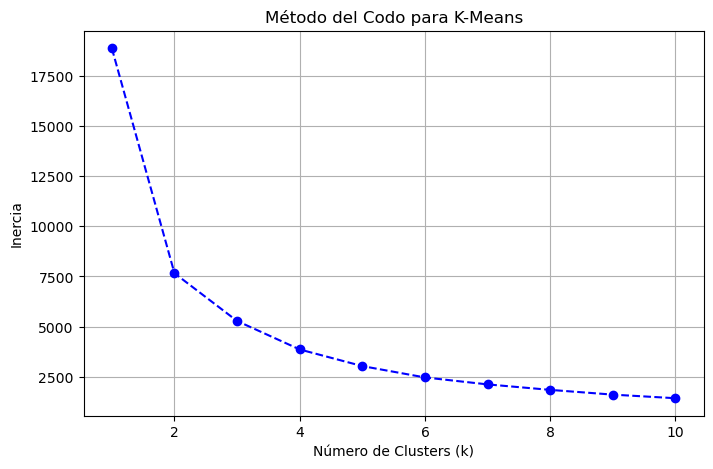

In [21]:
inercia = []
rango_k = range(1, 11)
for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_cluster)
    inercia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

### 3.3 Ejecución del algoritmo K-Means (k=3)

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

df_normal['CLUSTER_CRITICIDAD'] = kmeans.fit_predict(X_cluster)

### 3.4 Visualización de los Distritos Agrupados

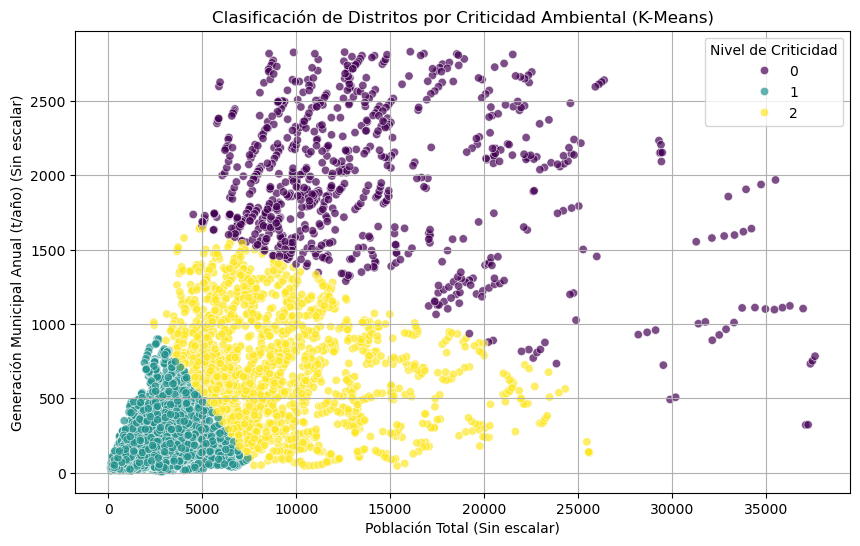

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=df_normal['POB_TOTAL_INEI'],
    y=df_normal['GENERACION_MUN_TANIO'],
    hue=df_normal['CLUSTER_CRITICIDAD'],
    palette='viridis',
    alpha=0.7
)
plt.title('Clasificación de Distritos por Criticidad Ambiental (K-Means)')
plt.xlabel('Población Total (Sin escalar)')
plt.ylabel('Generación Municipal Anual (t/año) (Sin escalar)')
plt.legend(title='Nivel de Criticidad')
plt.grid(True)
plt.show()

## 4. Predicción 
### 4.1 Preparación de la serie temporal

In [16]:
df_tendencia = df.groupby('ANIO')['GENERACION_MUN_TANIO'].sum().reset_index()
df_tendencia.head()

,ANIO,GENERACION_MUN_TANIO
0,2019,7781904.43
1,2020,7905118.11
2,2021,8214356.00
3,2022,8455715.42
4,2023,8706237.36


### 4.2 Entrenamiento del modelo de Regresión Lineal

In [17]:
df_train = df_tendencia[df_tendencia['ANIO'] <= 2023]
df_test = df_tendencia[df_tendencia['ANIO'] == 2024]


X_train = df_train[['ANIO']]
y_train = df_train['GENERACION_MUN_TANIO']


modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)

print("Modelo entrenado correctamente con datos de 2019-2023.")

Modelo entrenado correctamente con datos de 2019-2023.


### 4.3 Evaluación y comparación (2024)

In [18]:
X_test = df_test[['ANIO']]
prediccion_2024 = modelo_lr.predict(X_test)
valor_real_2024 = df_test['GENERACION_MUN_TANIO'].values[0]

print(f"Generación real en 2024: {valor_real_2024:,.2f} toneladas")
print(f"Predicción del modelo para 2024: {prediccion_2024[0]:,.2f} toneladas")
print(f"Error absoluto: {abs(valor_real_2024 - prediccion_2024[0]):,.2f} toneladas")

Generación real en 2024: 8,994,762.83 toneladas
Predicción del modelo para 2024: 8,932,445.22 toneladas
Error absoluto: 62,317.61 toneladas


### 4.4 Gráfica de la predicción vs tendencia histórica

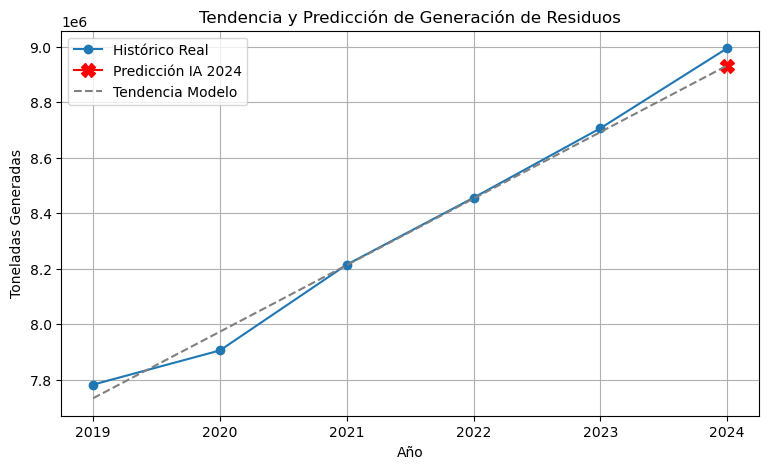

In [19]:
plt.figure(figsize=(9, 5))
plt.plot(df_tendencia['ANIO'], df_tendencia['GENERACION_MUN_TANIO'], marker='o', label='Histórico Real')
plt.plot(df_test['ANIO'], prediccion_2024, marker='X', color='red', markersize=10, label='Predicción IA 2024')


X_total = df_tendencia[['ANIO']]
plt.plot(X_total, modelo_lr.predict(X_total), linestyle='--', color='gray', label='Tendencia Modelo')

plt.title('Tendencia y Predicción de Generación de Residuos')
plt.xlabel('Año')
plt.ylabel('Toneladas Generadas')
plt.legend()
plt.grid(True)
plt.show()